# Multi-Head Attention with Weight Splits: A Visual Guide

## SECTION 0 — Big Picture

Welcome to this study notebook on Multi-Head Attention with Weight Splits. 

Here is the very simple visual pipeline of what we are going to do:
```text
Input embeddings
      ↓
Linear projection
      ↓
Q, K, V
      ↓
Split into attention heads
      ↓
Rearrange dimensions
      ↓
Q × Kᵀ
      ↓
Attention scores
      ↓
Causal mask
      ↓
Scale by √head_dim
      ↓
Softmax
      ↓
Attention weights
      ↓
Attention weights × V
      ↓
Context vectors per head
      ↓
Rearrange
      ↓
Concatenate heads
      ↓
Final context vectors
      ↓
Optional output projection
```

**What does this entire process accomplish?**
This process takes an input sequence of words and allows each word to look at all the other preceding words to understand its context. Instead of doing this just once, it splits the representation into multiple "heads," allowing the model to focus on different aspects of relationships (like grammar in one head, and vocabulary meaning in another) simultaneously. The "weight splits" approach calculates the projections for all these heads at once using one large matrix, which is computationally efficient. It then carefully reshapes and rearranges the data so each head can compute its attention independently. Finally, it merges the insights from all heads back together into a single, enriched representation for each word.

**Key Terminology with our example "The cat sleeps":**
- **Input embedding**: The initial numerical representation of "The", "cat", and "sleeps".
- **Query (Q)**: What a token is "looking for" (e.g., the query for "sleeps" might look for its subject).
- **Key (K)**: What a token "contains" (e.g., the key for "cat" says "I am a noun subject").
- **Value (V)**: The actual semantic content the token will pass along if it is attended to.
- **Attention score**: The raw dot product between a Query and a Key, representing basic compatibility.
- **Attention weight**: The normalized probability (after mask, scale, and softmax) indicating exactly how much of a Value to include.
- **Context vector**: The final weighted sum of Values for a specific token, containing its enriched meaning.



In [ ]:
#%pip install torch matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Set deterministic seed for reproducible results
torch.manual_seed(42)
np.random.seed(42)



## SECTION 1 — Input Tensor

Let's define our starting inputs:
- Batch size (B) = 1
- Number of tokens = 3
- Input embedding dimension (D_in) = 6

Our tokens are:
Token 1 → "The"
Token 2 → "cat"
Token 3 → "sleeps"



In [2]:
B = 1
num_tokens = 3
D_in = 6

# Create random but deterministic input embeddings
X = torch.randn(B, num_tokens, D_in)

print(f"Shape of X: {X.shape}")
print("Meaning:")
print(f"{X.shape[0]} = batch size")
print(f"{X.shape[1]} = number of tokens")
print(f"{X.shape[2]} = embedding dimensions per token")

print("\nInput Tensor X:")
print(X)

print("\nMapping:")
print(f"X[0, 0] -> embedding for 'The':\n{X[0, 0]}")
print(f"X[0, 1] -> embedding for 'cat':\n{X[0, 1]}")
print(f"X[0, 2] -> embedding for 'sleeps':\n{X[0, 2]}")



Shape of X: torch.Size([1, 3, 6])
Meaning:
1 = batch size
3 = number of tokens
6 = embedding dimensions per token

Input Tensor X:
tensor([[[ 1.9269,  1.4873, -0.4974,  0.4396, -0.7581,  1.0783],
         [ 0.8008,  1.6806,  0.3559, -0.6866,  0.6105,  1.3347],
         [-0.2316,  0.0418, -0.2516,  0.8599, -0.3097, -0.3957]]])

Mapping:
X[0, 0] -> embedding for 'The':
tensor([ 1.9269,  1.4873, -0.4974,  0.4396, -0.7581,  1.0783])
X[0, 1] -> embedding for 'cat':
tensor([ 0.8008,  1.6806,  0.3559, -0.6866,  0.6105,  1.3347])
X[0, 2] -> embedding for 'sleeps':
tensor([-0.2316,  0.0418, -0.2516,  0.8599, -0.3097, -0.3957])


## SECTION 2 — D_out, Number of Heads, Head Dimension

We want our output dimension to be 6, and we want to use 2 attention heads.
Because the total output dimension is split across the heads, each head gets a smaller portion of the dimension.

- `D_out = 6`
- `num_heads = 2`
- `head_dim = D_out / num_heads = 6 / 2 = 3`

Visual breakdown of D_out:
```text
D_out = 6
┌─────────────┬─────────────┐
│   Head 1    │   Head 2    │
│  3 values   │  3 values   │
└─────────────┴─────────────┘
```

Why do we split? By giving each head a smaller dimension (3 instead of 6), multiple heads can attend to different things in parallel without increasing the overall computational cost.



In [3]:
D_out = 6
num_heads = 2
head_dim = int(D_out / num_heads)

assert D_out % num_heads == 0, "D_out must be divisible by num_heads"

print(f"D_out: {D_out}")
print(f"num_heads: {num_heads}")
print(f"head_dim: {head_dim}")



D_out: 6
num_heads: 2
head_dim: 3


## SECTION 3 — Trainable W_Q, W_K, W_V

Now we define our trainable linear projection matrices. 
Instead of making separate matrices for each head, we make ONE large matrix for all queries, ONE for all keys, and ONE for all values.

Shapes:
- W_Q: (D_in, D_out) = (6, 6)
- W_K: (D_in, D_out) = (6, 6)
- W_V: (D_in, D_out) = (6, 6)

These are TRAINABLE parameters in a real neural network.

The process:
- X → W_Q → Q
- X → W_K → K
- X → W_V → V

Matrix multiplication explicitly:
`(1, 3, 6) × (6, 6) → (1, 3, 6)`

**IMPORTANT:** The *exact same* input embedding `X` is projected into three *different* representations (Q, K, V).



In [4]:
# Initialize linear layers with bias=False as per lecture
W_Q_layer = nn.Linear(D_in, D_out, bias=False)
W_K_layer = nn.Linear(D_in, D_out, bias=False)
W_V_layer = nn.Linear(D_in, D_out, bias=False)

# Let's inspect the weight shapes
# PyTorch stores weights as (out_features, in_features) so we transpose for visualization
print(f"W_Q shape: {W_Q_layer.weight.T.shape}") 
print(f"W_K shape: {W_K_layer.weight.T.shape}")
print(f"W_V shape: {W_V_layer.weight.T.shape}")



W_Q shape: torch.Size([6, 6])
W_K shape: torch.Size([6, 6])
W_V shape: torch.Size([6, 6])


## SECTION 4 — Produce Q, K, V

Let's compute our Queries, Keys, and Values.



In [5]:
Q = W_Q_layer(X)
K = W_K_layer(X)
V = W_V_layer(X)

print(f"Shape of Q: {Q.shape}")
print(f"Shape of K: {K.shape}")
print(f"Shape of V: {V.shape}")

print("\nMeaning of Q dimensions (1, 3, 6):")
print("batch = 1")
print("tokens = 3")
print("D_out = 6")

assert Q.shape == (B, num_tokens, D_out)

print("\nRow to Token mapping for Q:")
print(f"Token 1 ('The'):\n{Q[0, 0]}")
print(f"Token 2 ('cat'):\n{Q[0, 1]}")
print(f"Token 3 ('sleeps'):\n{Q[0, 2]}")



Shape of Q: torch.Size([1, 3, 6])
Shape of K: torch.Size([1, 3, 6])
Shape of V: torch.Size([1, 3, 6])

Meaning of Q dimensions (1, 3, 6):
batch = 1
tokens = 3
D_out = 6

Row to Token mapping for Q:
Token 1 ('The'):
tensor([ 0.0605, -0.2499,  0.4865, -0.1949, -0.1981, -0.2382],
       grad_fn=<SelectBackward0>)
Token 2 ('cat'):
tensor([-0.0306, -0.3815,  0.0989,  0.3073, -0.1420, -0.2298],
       grad_fn=<SelectBackward0>)
Token 3 ('sleeps'):
tensor([ 0.3460,  0.2377, -0.1301,  0.1652, -0.3155, -0.1540],
       grad_fn=<SelectBackward0>)


## SECTION 5 — SPLIT INTO MULTIPLE HEADS

**This is one of the MOST IMPORTANT sections.**

We take our tensor of shape `(1, 3, 6)` and reshape it into `(1, 3, 2, 3)`.

Where:
- 1 = batch
- 3 = tokens
- 2 = number of heads
- 3 = head dimension

Visually, Q looks like this now:
```text
Q:
Batch
 └── Token 1 ("The")
      ├── Head 1 → 3-dimensional vector
      └── Head 2 → 3-dimensional vector

 └── Token 2 ("cat")
      ├── Head 1 → 3-dimensional vector
      └── Head 2 → 3-dimensional vector

 └── Token 3 ("sleeps")
      ├── Head 1 → 3-dimensional vector
      └── Head 2 → 3-dimensional vector
```

**VERY CLEAR EXPLANATION:**
Notice that `6 = 2 × 3`.
The last dimension (6) is simply being reorganized into `(number of heads, head dimension)`.
We are NOT creating new information. We are only reshaping/reorganizing the existing 6 values so that the first 3 belong to Head 1, and the next 3 belong to Head 2.



In [6]:
Q_split = Q.view(B, num_tokens, num_heads, head_dim)
K_split = K.view(B, num_tokens, num_heads, head_dim)
V_split = V.view(B, num_tokens, num_heads, head_dim)

print(f"Shape of Q_split: {Q_split.shape}")
print("Meaning:")
print(f"{Q_split.shape[0]} = batch")
print(f"{Q_split.shape[1]} = tokens")
print(f"{Q_split.shape[2]} = number of heads")
print(f"{Q_split.shape[3]} = head dimension")

assert Q_split.shape == (B, num_tokens, num_heads, head_dim)



Shape of Q_split: torch.Size([1, 3, 2, 3])
Meaning:
1 = batch
3 = tokens
2 = number of heads
3 = head dimension


## SECTION 6 — WHY TRANSPOSE?

Currently, our shape is `(1, 3, 2, 3)`. 
The data is grouped by **TOKEN**. 

But for attention computation, we want each head to do its own matrix multiplication independently. So we want to group by **HEAD**.

Therefore, we change `(1, 3, 2, 3)` into `(1, 2, 3, 3)` using `transpose(1, 2)`.

```text
BEFORE (grouped by token):
Token 1
 ├── Head 1
 └── Head 2
Token 2
 ├── Head 1
 └── Head 2
Token 3
 ├── Head 1
 └── Head 2

AFTER (grouped by head):
Head 1
 ├── Token 1
 ├── Token 2
 └── Token 3
Head 2
 ├── Token 1
 ├── Token 2
 └── Token 3
```

Now, each head has a `(tokens × head_dim)` = `(3 × 3)` matrix!



In [7]:
Q_transposed = Q_split.transpose(1, 2)
K_transposed = K_split.transpose(1, 2)
V_transposed = V_split.transpose(1, 2)

print(f"Shape of Q_transposed: {Q_transposed.shape}")
print("Meaning:")
print(f"{Q_transposed.shape[0]} = batch")
print(f"{Q_transposed.shape[1]} = heads")
print(f"{Q_transposed.shape[2]} = tokens")
print(f"{Q_transposed.shape[3]} = head_dim")

assert Q_transposed.shape == (B, num_heads, num_tokens, head_dim)

print("\nLook at the shape for just ONE HEAD (Head 1):")
print(f"Head 1 Q shape: {Q_transposed[0, 0].shape}")
print(f"Head 2 Q shape: {Q_transposed[0, 1].shape}")



Shape of Q_transposed: torch.Size([1, 2, 3, 3])
Meaning:
1 = batch
2 = heads
3 = tokens
3 = head_dim

Look at the shape for just ONE HEAD (Head 1):
Head 1 Q shape: torch.Size([3, 3])
Head 2 Q shape: torch.Size([3, 3])


## SECTION 7 — Q × Kᵀ

Now we calculate the attention scores. Because Q and K are grouped by head, each head performs its own attention calculation perfectly!

Formula: `attention_scores = Q @ K.transpose(2, 3)`
(Note: we transpose the last two dimensions of K to make it `head_dim × tokens`).

For ONE HEAD explicitly:
- Q_head1 shape: `(3, 3)`
- K_head1 shape: `(3, 3)`
- K_head1ᵀ shape: `(3, 3)`  (because it flips 3×3 to 3×3)

Therefore: `(3, 3) × (3, 3) → (3, 3)`

The resulting `3×3` matrix is the attention score matrix for that head.

```text
             KEY
             The   cat   sleeps
QUERY The
      cat
      sleeps
```

**VERY IMPORTANT:**
- **row = query token**
- **column = key token**

Therefore, `attention_scores[cat, The]` means: "How strongly does the query 'cat' relate to the key 'The'?"
And `attention_scores[sleeps, cat]` means: "How strongly does the query 'sleeps' relate to the key 'cat'?"



In [8]:
# We transpose dimensions 2 and 3 of K
K_T = K_transposed.transpose(2, 3)

# Calculate scores
attention_scores = Q_transposed @ K_T

print(f"Shape of attention_scores: {attention_scores.shape}")
print("\nLet's view the 3x3 attention score matrix for Head 1:")
print(attention_scores[0, 0])



Shape of attention_scores: torch.Size([1, 2, 3, 3])

Let's view the 3x3 attention score matrix for Head 1:
tensor([[-0.1309,  0.0571, -0.2110],
        [ 0.0655,  0.2082, -0.1992],
        [ 0.1672, -0.0420,  0.0637]], grad_fn=<SelectBackward0>)


## SECTION 8 — ATTENTION SCORE TENSOR

The complete shape of `attention_scores` is `(1, 2, 3, 3)`.

Meaning of EVERY dimension:
- 1 → batch
- 2 → attention heads
- 3 → query tokens
- 3 → key tokens

Visually:
```text
Batch 1
 ├── Head 1 → 3×3 attention matrix
 └── Head 2 → 3×3 attention matrix
```

Why two separate 3×3 matrices? Because we have 2 heads, and each head learns different relationship patterns between the words.



In [9]:
assert attention_scores.shape == (B, num_heads, num_tokens, num_tokens)

print("Shape:", attention_scores.shape)
print("\nMeaning:")
print("1 batch")
print("2 attention heads")
print("3 query tokens")
print("3 key tokens")



Shape: torch.Size([1, 2, 3, 3])

Meaning:
1 batch
2 attention heads
3 query tokens
3 key tokens


## SECTION 9 — CAUSAL MASK

During autoregressive GPT training, a token must not use information from future tokens.

For "The cat sleeps":
- The query "The" cannot look at: "cat", "sleeps"
- The query "cat" cannot look at: "sleeps"
- The query "sleeps" can look at: "The", "cat", "sleeps"

We create an upper-triangular causal mask:
```text
       The   cat   sleeps
The     ✓     ✗      ✗
cat     ✓     ✓      ✗
sleeps  ✓     ✓      ✓
```

Future positions are replaced with `-infinity`.
**WHY `-infinity`?** Because the next step (softmax) turns `-infinity` into exactly `0` probability. This strictly prevents future tokens from leaking into the current context.



In [10]:
# Create an upper triangular mask (1s above the diagonal)
mask = torch.triu(torch.ones(num_tokens, num_tokens), diagonal=1).bool()

print("Mask (True means it will be masked out):")
print(mask)

print("\nBEFORE Masking (Head 1):")
print(attention_scores[0, 0])

# Apply the mask: replace masked positions with -inf
attention_scores_masked = attention_scores.masked_fill(mask, float('-inf'))

print("\nAFTER Masking (Head 1):")
print(attention_scores_masked[0, 0])



Mask (True means it will be masked out):
tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

BEFORE Masking (Head 1):
tensor([[-0.1309,  0.0571, -0.2110],
        [ 0.0655,  0.2082, -0.1992],
        [ 0.1672, -0.0420,  0.0637]], grad_fn=<SelectBackward0>)

AFTER Masking (Head 1):
tensor([[-0.1309,    -inf,    -inf],
        [ 0.0655,  0.2082,    -inf],
        [ 0.1672, -0.0420,  0.0637]], grad_fn=<SelectBackward0>)


## SECTION 10 — SCALE BY sqrt(head_dim)

We scale the scores by dividing by the square root of `head_dim`.

Here: `head_dim = 3`, so we divide by `sqrt(3)`.

**WHY?**
As `head_dim` increases, dot products between random vectors grow larger. This pushes the softmax function into regions where gradients are very small (the "flat" tails). Scaling helps keep the variance of the values in a suitable range, leading to stable gradients.



In [11]:
print("BEFORE Scaling (Head 1):")
print(attention_scores_masked[0, 0])

attention_scores_scaled = attention_scores_masked / math.sqrt(head_dim)

print(f"\nAFTER Scaling by sqrt(3)={math.sqrt(3):.4f} (Head 1):")
print(attention_scores_scaled[0, 0])



BEFORE Scaling (Head 1):
tensor([[-0.1309,    -inf,    -inf],
        [ 0.0655,  0.2082,    -inf],
        [ 0.1672, -0.0420,  0.0637]], grad_fn=<SelectBackward0>)

AFTER Scaling by sqrt(3)=1.7321 (Head 1):
tensor([[-0.0756,    -inf,    -inf],
        [ 0.0378,  0.1202,    -inf],
        [ 0.0966, -0.0242,  0.0368]], grad_fn=<SelectBackward0>)


## SECTION 11 — SOFTMAX

Now we apply `softmax(dim=-1)`.

Softmax is applied across the LAST dimension (the key tokens).
For each query row, all attention weights will sum to 1.0.

Raw scores on a row like `[2.0, 1.0, -inf]` will become probabilities like `[~0.73, ~0.27, 0.0]`.

**MOST IMPORTANT EXPLANATION:**
`attention score` ≠ `attention weight`
- **Attention score**: raw compatibility value (dot product)
- **Attention weight**: normalized probability value between 0 and 1 (after mask, scale, and softmax)



Attention Weights (Head 1):
tensor([[1.0000, 0.0000, 0.0000],
        [0.4794, 0.5206, 0.0000],
        [0.3536, 0.3134, 0.3331]], grad_fn=<SelectBackward0>)

Row sums: tensor([1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>) (should be 1s)


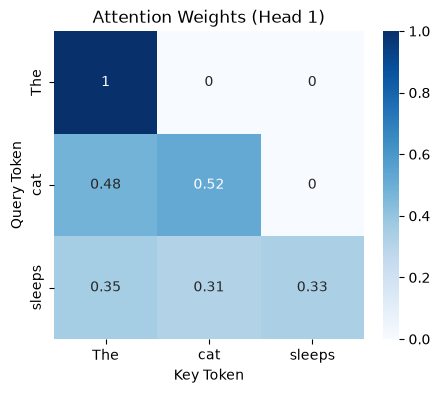

In [12]:
attention_weights = torch.softmax(attention_scores_scaled, dim=-1)

print("Attention Weights (Head 1):")
print(attention_weights[0, 0])

# Verify rows sum to 1
row_sums = attention_weights[0, 0].sum(dim=-1)
print(f"\nRow sums: {row_sums} (should be 1s)")

# Let's visualize the heatmap for Head 1
plt.figure(figsize=(5,4))
sns.heatmap(attention_weights[0, 0].detach().numpy(), annot=True, cmap="Blues",
            xticklabels=["The", "cat", "sleeps"], 
            yticklabels=["The", "cat", "sleeps"])
plt.title("Attention Weights (Head 1)")
plt.xlabel("Key Token")
plt.ylabel("Query Token")
plt.show()



## SECTION 12 — ATTENTION WEIGHTS × VALUES

Now we use: `context = attention_weights @ V`

Dimensions:
- attention_weights: `(B, heads, tokens, tokens)` = `(1, 2, 3, 3)`
- V (V_transposed): `(B, heads, tokens, head_dim)` = `(1, 2, 3, 3)`

Matrix multiplication for each head:
`(tokens × tokens) × (tokens × head_dim)` = `(tokens × head_dim)`
`(3, 3) × (3, 3) → (3, 3)`

Let's use one concrete row.
Context vector for "cat" = 
`weight(cat→The) × V(The)` + `weight(cat→cat) × V(cat)` + `weight(cat→sleeps) × V(sleeps)`

Since our causal mask made the future weight zero, `weight(cat→sleeps) = 0`. The "cat" context cannot use "sleeps"!



In [13]:
context_per_head = attention_weights @ V_transposed

print(f"Shape of context_per_head: {context_per_head.shape}")
print("Meaning:")
print(f"{context_per_head.shape[0]} batch")
print(f"{context_per_head.shape[1]} heads")
print(f"{context_per_head.shape[2]} tokens")
print(f"{context_per_head.shape[3]} head_dim")



Shape of context_per_head: torch.Size([1, 2, 3, 3])
Meaning:
1 batch
2 heads
3 tokens
3 head_dim


## SECTION 13 — CONTEXT VECTOR PER HEAD

Final shape: `(1, 2, 3, 3)`

- **Head 1**: 3 tokens × 3-dimensional context vector
- **Head 2**: 3 tokens × 3-dimensional context vector

Let's see the actual values for both heads.



In [14]:
print("Head 1 Context Vectors:\n", context_per_head[0, 0])
print("\nHead 2 Context Vectors:\n", context_per_head[0, 1])



Head 1 Context Vectors:
 tensor([[-1.1645, -0.6860, -1.0467],
        [-0.6894, -0.8400, -0.9356],
        [-0.5638, -0.5409, -0.6253]], grad_fn=<SelectBackward0>)

Head 2 Context Vectors:
 tensor([[-1.3132,  1.0786, -1.8357],
        [-0.8220,  0.4764, -1.5111],
        [-0.6882,  0.4630, -1.1068]], grad_fn=<SelectBackward0>)


## SECTION 14 — TRANSPOSE CONTEXT

Now reproduce: `context_per_head.transpose(1, 2)`

Current shape: `(1, 2, 3, 3)` `(B, heads, tokens, head_dim)`
Change to: `(1, 3, 2, 3)` `(B, tokens, heads, head_dim)`

**WHY do we do this?**
We eventually want to combine the head dimension and head count back into `D_out`. To do that, the data needs to be grouped by Token again.

```text
Token 1
 ├── Head 1 → 3 values
 └── Head 2 → 3 values
Token 2
 ├── Head 1 → 3 values
 └── Head 2 → 3 values
Token 3
 ├── Head 1 → 3 values
 └── Head 2 → 3 values
```



In [15]:
context_transposed_back = context_per_head.transpose(1, 2)

print(f"Shape after transpose: {context_transposed_back.shape}")
assert context_transposed_back.shape == (B, num_tokens, num_heads, head_dim)



Shape after transpose: torch.Size([1, 3, 2, 3])


## SECTION 15 — CONCATENATE / MERGE HEADS

Now we combine: `heads × head_dim` = `2 × 3` = `6`.

So `(1, 3, 2, 3)` becomes `(1, 3, 6)`.

We split `D_out` earlier (6 → 2 heads × 3 dimensions), and now we merge them back (2 × 3 → 6).
This is NOT losing the separate head information; the outputs are placed side-by-side (concatenated) into the final representation.

Explicitly for Token 1:
- Head 1: `[a, b, c]`
- Head 2: `[d, e, f]`
- After concatenation: `[a, b, c, d, e, f]`



In [16]:
# We will do this using view() in the next section.
# Conceptually, this step flattens the last two dimensions.
pass



## SECTION 16 — CONTIGUOUS + RESHAPE

PyTorch code often contains:
`context.contiguous().view(B, num_tokens, D_out)`

**Explanation:**
`transpose` changes how a tensor is read, but doesn't move the data in memory.
`contiguous()` ensures the tensor has a clean, compatible memory layout before we mash the dimensions together with `view()` (which acts like reshape).

Shape transformation:
`(1, 3, 2, 3) → (1, 3, 6)`



In [17]:
context_merged = context_transposed_back.contiguous().view(B, num_tokens, D_out)

print(f"Merged Context Shape: {context_merged.shape}")
assert context_merged.shape == (B, num_tokens, D_out)

print("\nMerged Context for Token 1 ('The'):")
print(context_merged[0, 0])



Merged Context Shape: torch.Size([1, 3, 6])

Merged Context for Token 1 ('The'):
tensor([-1.1645, -0.6860, -1.0467, -1.3132,  1.0786, -1.8357],
       grad_fn=<SelectBackward0>)


## SECTION 17 — OPTIONAL OUTPUT PROJECTION

Finally, we apply an optional learned projection after concatenating the heads:
`out_proj = nn.Linear(D_out, D_out, bias=False)`

Shape transformation:
`(1, 3, 6) → (1, 3, 6)`

This projection is separate from `W_Q`, `W_K`, and `W_V`. It mixes the concatenated head information together.



In [18]:
out_proj = nn.Linear(D_out, D_out, bias=False)
final_output = out_proj(context_merged)

print(f"Final Output Shape: {final_output.shape}")



Final Output Shape: torch.Size([1, 3, 6])


## SECTION 18 — COMPLETE 11-STEP PIPELINE

Here is the clean visual summary matching the demonstration:

| Step | Operation | Shape | Meaning |
|---|---|---|---|
| 1 | Input X | `(1, 3, 6)` | 1 batch, 3 tokens, 6-dim embed |
| 2 | Define parameters | `head_dim=3` | 2 heads, 3-dim per head |
| 3 | Apply W_Q, W_K, W_V | `(1, 3, 6)` for Q, K, V | Projected features |
| 4 | Reshape to split heads | `(1, 3, 2, 3)` | Grouped by token, 2 heads |
| 5 | Transpose `(1,2)` | `(1, 2, 3, 3)` | Grouped by head |
| 6 | Q × Kᵀ | `(1, 2, 3, 3)` | Raw attention scores |
| 7 | Causal Mask | `(1, 2, 3, 3)` | Future tokens set to -inf |
| 8 | Scale & Softmax | `(1, 2, 3, 3)` | Normalized attention weights |
| 9 | Weights × V | `(1, 2, 3, 3)` | Context vectors per head |
| 10 | Transpose context | `(1, 3, 2, 3)` | Grouped by token again |
| 11 | Merge heads (reshape) | `(1, 3, 6)` | Final concatenated context |



In [19]:
# A quick summary function reproducing the pipeline from start to finish
def multi_head_attention(X, W_Q, W_K, W_V, num_heads):
    B, num_tokens, D_in = X.shape
    D_out = W_Q.out_features
    head_dim = D_out // num_heads
    
    Q = W_Q(X).view(B, num_tokens, num_heads, head_dim).transpose(1, 2)
    K = W_K(X).view(B, num_tokens, num_heads, head_dim).transpose(1, 2)
    V = W_V(X).view(B, num_tokens, num_heads, head_dim).transpose(1, 2)
    
    scores = Q @ K.transpose(-2, -1)
    mask = torch.triu(torch.ones(num_tokens, num_tokens), diagonal=1).bool()
    scores = scores.masked_fill(mask, float('-inf'))
    
    weights = torch.softmax(scores / math.sqrt(head_dim), dim=-1)
    
    context = (weights @ V).transpose(1, 2).contiguous().view(B, num_tokens, D_out)
    return context

print("Pipeline function works! Output shape:", multi_head_attention(X, W_Q_layer, W_K_layer, W_V_layer, num_heads).shape)



Pipeline function works! Output shape: torch.Size([1, 3, 6])


## SECTION 19 — MULTIPLE BATCHES

Now change: `B = 1` to `B = 2`

We create two simple batches. The exact same attention operations happen independently for each batch.
Batching allows multiple sequences to be processed simultaneously.

The batch dimension does NOT mean the sequences attend to each other. "The cat sleeps" doesn't care about the sentence in batch 2.



In [ ]:
X_batch = torch.randn(2, 3, 6) # (B=2, tokens=3, D_in=6)

out_batch = multi_head_attention(X_batch, W_Q_layer, W_K_layer, W_V_layer, num_heads=2)

print(f"Input shape: {X_batch.shape}")
print(f"Final context shape: {out_batch.shape}")
print("\nNotice how B=2 passes through seamlessly!")



## SECTION 20 — WEIGHT SPLITS VS PREVIOUS IMPLEMENTATION

**The Previous Approach (Separate Matrices):**
For 2 heads, we would do:
- X × W_Q1 → Q1
- X × W_Q2 → Q2
- (Same for K and V)

**The Weight-Split Approach (Our Approach):**
- X × W_Q → Q

where `W_Q` already contains the dimensions needed for all heads. We then split the resulting Q into heads.

```text
PREVIOUS:
X
├── WQ1 → Q1
└── WQ2 → Q2

NEW:
X
└── WQ → Q
          ├── Q1
          └── Q2
```

**Computational Motivation:**
Fewer separate matrix multiplications at the beginning. Launching one large matrix multiplication on a GPU is significantly more efficient than launching multiple smaller ones, even if the total number of mathematical operations is identical.



In [ ]:
# Just a placeholder cell to visually separate sections
pass



## SECTION 21 — DIMENSION SURVIVAL GUIDE

Never get lost in dimensions again!

**3D Tensor:**
`(B, tokens, D_out)`

**4D Tensor:**
`(B, heads, tokens, head_dim)`

Let's break down `(1, 2, 3, 3)` visually:
- `1` → one batch
- `2` → two heads
- `3` → three tokens
- `3` → three values per head

**The Journey of Shapes:**
1. **Input:** `(B, tokens, D_in)`
2. **Q, K, V:** `(B, tokens, D_out)`
3. **Reshape:** `(B, tokens, heads, head_dim)`
4. **Transpose:** `(B, heads, tokens, head_dim)`
5. **Attention Scores:** `(B, heads, tokens, tokens)`
6. **Context:** `(B, heads, tokens, head_dim)`
7. **Transpose back:** `(B, tokens, heads, head_dim)`
8. **Final:** `(B, tokens, D_out)`



In [ ]:
pass



## SECTION 22 — INTERACTIVE EXPLORATION

Try changing these values yourself to see how the shapes update!
Remember: `D_out` must be divisible by `num_heads`.



In [20]:
# Manual interactive cell
# Change these values and run!
my_tokens = 5
my_D_out = 8
my_num_heads = 4

# Calculated automatically:
my_head_dim = my_D_out // my_num_heads
print(f"Calculated head_dim: {my_head_dim}")
print(f"Tensor shape before transpose: (1, {my_tokens}, {my_num_heads}, {my_head_dim})")
print(f"Tensor shape after transpose: (1, {my_num_heads}, {my_tokens}, {my_head_dim})")
print(f"Attention scores shape: (1, {my_num_heads}, {my_tokens}, {my_tokens})")



Calculated head_dim: 2
Tensor shape before transpose: (1, 5, 4, 2)
Tensor shape after transpose: (1, 4, 5, 2)
Attention scores shape: (1, 4, 5, 5)


## SECTION 23 — FINAL VISUAL ATTENTION MAP

Let's visualize the attention weights for both heads clearly.
Notice the triangular causal structure: the upper right is always exactly zero (represented by the dark/empty color depending on cmap).



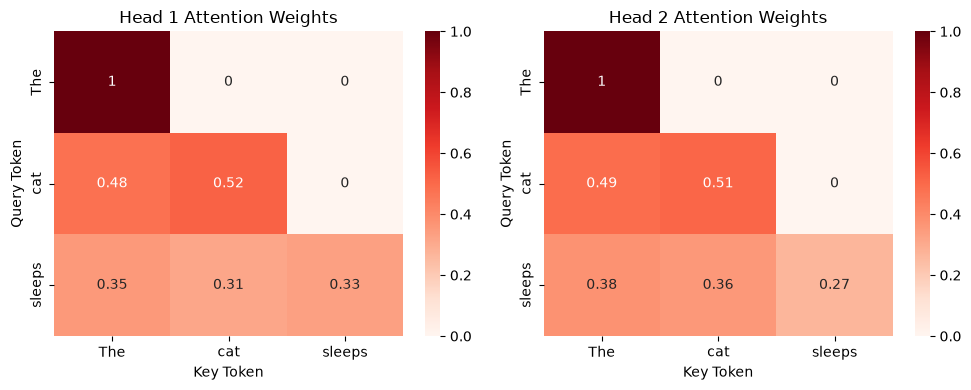

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
tokens_list = ["The", "cat", "sleeps"]

for i in range(2):
    sns.heatmap(attention_weights[0, i].detach().numpy(), annot=True, cmap="Reds", 
                xticklabels=tokens_list, yticklabels=tokens_list, ax=axes[i], vmin=0, vmax=1)
    axes[i].set_title(f"Head {i+1} Attention Weights")
    axes[i].set_xlabel("Key Token")
    axes[i].set_ylabel("Query Token")

plt.tight_layout()
plt.show()



## SECTION 24 — FINAL "TRACE ONE TOKEN" EXERCISE

Let's pick the token: **"cat"** (Index 1) and trace its journey!

```text
"cat" embedding (Shape: 6)
       ↓
"cat" query, key, value (Projected to 6, split to 3 and 3)
       ↓
"cat" query compared with every key (The, cat, sleeps)
       ↓
Raw attention scores for "cat": [Score(cat, The), Score(cat, cat), Score(cat, sleeps)]
       ↓
Causal mask applied: [Score(cat, The), Score(cat, cat), -infinity] (Cannot look at "sleeps")
       ↓
Scaling by 1/√3
       ↓
Softmax applied: [Weight1, Weight2, 0] (Sum to 1)
       ↓
Weighted combination of values: 
(Weight1 * V_The) + (Weight2 * V_cat) + (0 * V_sleeps)
       ↓
"cat" context vector for Head 1 (Shape: 3)
"cat" context vector for Head 2 (Shape: 3)
       ↓
Concatenated "cat" context vector (Shape: 6)
```



In [ ]:
print("Trace Complete! Review the text block above carefully.")



## SECTION 25 — SELF TEST

Test your understanding! Try to answer these before looking at the answers below.

1. Why is D_out divided by the number of heads?
2. Why does Q initially have shape (B, tokens, D_out)?
3. Why does it become (B, tokens, heads, head_dim)?
4. Why do we transpose to (B, heads, tokens, head_dim)?
5. What does one element of QKᵀ represent?
6. Why is the attention score matrix tokens × tokens?
7. Why are future positions replaced with -inf?
8. Why does softmax use dim=-1?
9. Why do we multiply attention weights by V rather than K?
10. Why do we merge heads back into D_out?

<details>
<summary>Click to reveal answers</summary>

1. To keep computational cost constant while allowing the model to attend to multiple different "aspects" of the text in parallel.
2. Because the single W_Q projection matrix projects the D_in embedding into the full D_out dimension.
3. We are simply splitting the D_out dimension into equal slices, one for each head.
4. PyTorch matrix multiplication `A @ B` acts on the last two dimensions. We need `tokens × head_dim` to be the last two dimensions so each head computes attention independently.
5. A raw "compatibility" score between one specific query token and one specific key token.
6. Because it represents every query token's score against every key token in the sequence.
7. So that when passed through softmax, their probability becomes exactly 0, preventing information flow from the future.
8. Because we want the probabilities *across all keys* (the last dimension) for a given query to sum to 1.
9. Keys are for matching (like a dictionary key). Values hold the actual semantic payload to be aggregated.
10. So the next layer of the neural network receives a single continuous vector per token of size D_out, rather than separated head fragments.
</details>

---
### FINAL VISUAL COMPANION
```text
X
│
├── W_Q → Q ──┐
├── W_K → K ──┼→ QKᵀ → mask → scale → softmax
└── W_V → V ──┘                    │
                                   ↓
                              attention weights
                                   │
                                   ×
                                   V
                                   ↓
                              context/head
                                   ↓
                            merge all heads
                                   ↓
                           final context X'
```

